In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [16]:
DATA_PATH = Path("data/egx")

csv_files = list(DATA_PATH.glob("*.csv"))

print(f"Number of stocks: {len(csv_files)}")
print("Stocks:")

for file in csv_files:
    print(file.stem)

Number of stocks: 34
Stocks:
ABUK
ADIB
ALCN
AMOC
ARCC
BTFH
CCAP
CIEB
COMI
DOMTY
EAST
EFID
EFIH
EGAL
EMFD
ETEL
FWRY
GBCO
HELI
HRHO
ISPH
JUFO
MCQE
MFPC
ORAS
ORWE
PHDC
RAYA
RMDA
SAUD
SKPC
SUGR
SWDY
TMGH


In [17]:
sample_file = csv_files[0]

df = pd.read_csv(sample_file)

print("File:", sample_file.name)
print()
print(df.head())
print()
print(df.columns.tolist())
print()
print(df.shape)

File: ABUK.csv

         date       open       high        low      close  volume
0  2015-01-04  10.666666  10.666666  10.666666  10.666666       0
1  2015-01-05  10.666666  10.800000  10.373333  10.794666  295290
2  2015-01-06  10.794666  10.800000  10.800000  10.800000  765000
3  2015-01-08  10.800000  10.400666  10.400666  10.800000     255
4  2015-01-11  10.800000  10.800000  10.800000  10.800000       0

['date', 'open', 'high', 'low', 'close', 'volume']

(2857, 6)


In [18]:
prices = {}

for file in csv_files:
    symbol = file.stem
    
    df = pd.read_csv(file)
    df["date"] = pd.to_datetime(df["date"])
    
    df = df.sort_values("date")
    df = df.set_index("date")
    
    prices[symbol] = df["close"]

prices = pd.DataFrame(prices)

prices.head()

,ABUK,ADIB,ALCN,AMOC,ARCC,BTFH,CCAP,CIEB,COMI,DOMTY,...,ORAS,ORWE,PHDC,RAYA,RMDA,SAUD,SKPC,SUGR,SWDY,TMGH
date,,,,,,,,,,,,,,,,,,,,,
2015-01-04,10.666666,5.525075,3.847666,4.073333,16.950001,6.884735,2.90,4.362539,15.774424,NaN,...,NaN,8.014666,3.249314,0.215294,NaN,2.03802,10.506944,15.420000,4.168,9.89
2015-01-05,10.794666,5.540275,3.789166,4.001333,16.590000,6.972907,2.93,4.463566,15.870143,NaN,...,NaN,8.464000,3.257220,0.220000,NaN,2.03802,10.694444,16.350000,4.248,9.95
2015-01-06,10.800000,5.684672,3.715333,3.996000,16.080000,6.719413,2.81,4.463566,15.512794,NaN,...,NaN,8.686666,3.107009,0.210980,NaN,2.03802,10.347222,15.910000,4.223,9.71
2015-01-08,10.800000,5.851868,3.666666,3.997333,16.000000,6.936169,2.87,4.463566,15.825474,NaN,...,NaN,8.809333,3.186067,0.209803,NaN,2.03802,10.472222,15.910000,4.252,9.90
2015-01-11,10.800000,5.715071,3.666666,3.976666,15.930000,6.925147,2.83,4.463566,15.790377,NaN,...,NaN,8.881333,3.225597,0.210196,NaN,2.03802,10.444444,16.139999,4.245,9.76


In [19]:
print("Shape:", prices.shape)

print("\nMissing values:")
print(prices.isna().sum())

print("\nColumns:")
print(prices.columns.tolist())

Shape: (2868, 34)

Missing values:
ABUK       11
ADIB        7
ALCN       11
AMOC       11
ARCC       11
BTFH        9
CCAP       11
CIEB        9
COMI        7
DOMTY     523
EAST       11
EFID       81
EFIH     1707
EGAL       10
EMFD      137
ETEL        8
FWRY     1175
GBCO       11
HELI        7
HRHO        5
ISPH      741
JUFO       11
MCQE       10
MFPC      438
ORAS     1655
ORWE       10
PHDC        7
RAYA        6
RMDA     1258
SAUD        9
SKPC        7
SUGR       11
SWDY       11
TMGH       11
dtype: int64

Columns:
['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']


In [20]:
returns = prices.pct_change()

returns.head()

,ABUK,ADIB,ALCN,AMOC,ARCC,BTFH,CCAP,CIEB,COMI,DOMTY,...,ORAS,ORWE,PHDC,RAYA,RMDA,SAUD,SKPC,SUGR,SWDY,TMGH
date,,,,,,,,,,,,,,,,,,,,,
2015-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,0.012000,0.002751,-0.015204,-0.017676,-0.021239,0.012807,0.010345,0.023158,0.006068,NaN,...,NaN,0.056064,0.002433,0.021858,NaN,0.0,0.017845,0.060311,0.019194,0.006067
2015-01-06,0.000494,0.026063,-0.019485,-0.001333,-0.030741,-0.036354,-0.040956,0.000000,-0.022517,NaN,...,NaN,0.026307,-0.046116,-0.041000,NaN,0.0,-0.032467,-0.026911,-0.005885,-0.024121
2015-01-08,0.000000,0.029412,-0.013099,0.000334,-0.004975,0.032258,0.021352,0.000000,0.020156,NaN,...,NaN,0.014121,0.025445,-0.005579,NaN,0.0,0.012081,0.000000,0.006867,0.019567
2015-01-11,0.000000,-0.023377,0.000000,-0.005170,-0.004375,-0.001589,-0.013937,0.000000,-0.002218,NaN,...,NaN,0.008173,0.012407,0.001873,NaN,0.0,-0.002653,0.014456,-0.001646,-0.014141


In [21]:
returns = returns.dropna()

returns.head()

,ABUK,ADIB,ALCN,AMOC,ARCC,BTFH,CCAP,CIEB,COMI,DOMTY,...,ORAS,ORWE,PHDC,RAYA,RMDA,SAUD,SKPC,SUGR,SWDY,TMGH
date,,,,,,,,,,,,,,,,,,,,,
2021-10-24,0.105076,-0.017027,0.012376,0.007371,0.028902,-0.014459,0.010673,0.006769,0.003810,0.004890,...,0.0,0.013095,-0.006619,0.000000,0.001669,0.0,0.022941,0.023418,0.009456,-0.001377
2021-10-25,0.010106,0.002665,-0.020782,-0.026829,-0.025281,-0.045188,-0.030057,-0.002615,0.020451,0.019465,...,0.0,-0.014101,-0.000513,-0.114504,0.016667,0.0,-0.019368,-0.042053,-0.003513,0.001379
2021-10-26,0.012733,-0.026578,-0.003745,0.047619,0.051873,-0.073141,0.005025,0.029962,0.002479,-0.019093,...,0.0,-0.015495,-0.002564,0.012931,-0.027869,0.0,0.065489,-0.032924,0.005875,0.015151
2021-10-27,-0.028289,-0.008191,-0.013784,-0.021531,-0.016438,0.025862,0.014167,-0.002182,0.030503,0.021898,...,0.0,-0.010896,0.003085,0.000000,-0.051714,0.0,-0.015610,0.001335,0.001168,-0.010855
2021-10-28,-0.006469,0.012388,0.013977,0.026895,0.030641,0.020685,0.004930,-0.005831,0.020200,0.030952,...,0.0,0.008568,-0.015889,0.029787,0.060462,0.0,0.016848,0.012667,0.003501,0.015089


In [22]:
annual_returns = returns.mean() * 252

annual_returns

ABUK     0.350649
ADIB     0.426050
ALCN     0.408060
AMOC     0.250943
ARCC     0.705265
BTFH     0.329171
CCAP     0.408838
CIEB     0.327503
COMI     0.371920
DOMTY    0.473913
EAST     0.320307
EFID     0.382853
EFIH     0.119818
EGAL     0.608666
EMFD     0.379221
ETEL     0.471711
FWRY     0.243644
GBCO     0.516445
HELI     0.295722
HRHO     0.315133
ISPH     0.385011
JUFO     0.393311
MCQE     0.749534
MFPC     0.166702
ORAS     0.000000
ORWE     0.283992
PHDC     0.499382
RAYA     0.384453
RMDA     0.402398
SAUD     0.408105
SKPC     0.272394
SUGR     0.329817
SWDY     0.600977
TMGH     0.622022
dtype: float64

In [23]:
cov_matrix = returns.cov() * 252

cov_matrix

,ABUK,ADIB,ALCN,AMOC,ARCC,BTFH,CCAP,CIEB,COMI,DOMTY,...,ORAS,ORWE,PHDC,RAYA,RMDA,SAUD,SKPC,SUGR,SWDY,TMGH
ABUK,0.165866,0.040766,0.090020,0.075258,0.019133,0.030909,0.054220,0.040736,0.027182,0.014104,...,0.0,0.056257,0.025701,0.035887,0.014903,0.026863,0.089606,0.064244,0.054410,0.025993
ADIB,0.040766,0.226884,0.055006,0.040688,0.026763,0.052711,0.056580,0.062533,0.039978,0.018419,...,0.0,0.049536,0.048515,0.050941,0.038960,0.041767,0.053502,0.043314,0.050975,0.057129
ALCN,0.090020,0.055006,0.308717,0.085936,0.031669,0.063780,0.086633,0.055805,0.039724,0.028225,...,0.0,0.081329,0.057282,0.047482,0.041213,0.032708,0.111329,0.093389,0.086568,0.043313
AMOC,0.075258,0.040688,0.085936,0.162207,0.020768,0.043564,0.077682,0.041252,0.021152,0.024996,...,0.0,0.055816,0.048219,0.046607,0.030010,0.030265,0.106092,0.058118,0.073722,0.041770
ARCC,0.019133,0.026763,0.031669,0.020768,0.230434,0.051618,0.057397,0.032076,0.022735,0.026959,...,0.0,0.028196,0.058976,0.052289,0.037939,0.028635,0.032231,0.029514,0.046764,0.052129
BTFH,0.030909,0.052711,0.063780,0.043564,0.051618,0.415040,0.089829,0.034159,0.026674,0.040521,...,0.0,0.047848,0.073820,0.072189,0.053182,0.032763,0.061408,0.060828,0.063713,0.049447
CCAP,0.054220,0.056580,0.086633,0.077682,0.057397,0.089829,0.265212,0.058066,0.035223,0.040529,...,0.0,0.070407,0.084185,0.075493,0.059092,0.037554,0.087775,0.070276,0.086190,0.063003
CIEB,0.040736,0.062533,0.055805,0.041252,0.032076,0.034159,0.058066,0.142974,0.039581,0.021813,...,0.0,0.053792,0.043843,0.041506,0.033899,0.039308,0.055021,0.039835,0.051633,0.048046
COMI,0.027182,0.039978,0.039724,0.021152,0.022735,0.026674,0.035223,0.039581,0.104524,0.012329,...,0.0,0.042621,0.034921,0.031584,0.023958,0.028865,0.036275,0.029961,0.041684,0.031314
DOMTY,0.014104,0.018419,0.028225,0.024996,0.026959,0.040521,0.040529,0.021813,0.012329,0.188673,...,0.0,0.032764,0.033865,0.033431,0.021062,0.028008,0.025210,0.023085,0.026565,0.033233


In [24]:
summary = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": np.sqrt(np.diag(cov_matrix))
})

summary

,Annual Return,Annual Volatility
ABUK,0.350649,0.407267
ADIB,0.426050,0.476324
ALCN,0.408060,0.555623
AMOC,0.250943,0.402749
ARCC,0.705265,0.480035
BTFH,0.329171,0.644236
CCAP,0.408838,0.514987
CIEB,0.327503,0.378119
COMI,0.371920,0.323301
DOMTY,0.473913,0.434366


In [25]:
def portfolio_performance(weights, returns, cov_matrix):
    portfolio_return = np.dot(weights, returns)
    
    portfolio_variance = np.dot(
        weights.T,
        np.dot(cov_matrix, weights)
    )
    
    portfolio_risk = np.sqrt(portfolio_variance)
    
    return portfolio_return, portfolio_risk

In [26]:
n_portfolios = 50_000

n_assets = len(annual_returns)

portfolio_returns = []
portfolio_risks = []
portfolio_weights = []

np.random.seed(42)

for _ in range(n_portfolios):
    
    # Generate random weights
    weights = np.random.random(n_assets)
    
    # Make weights sum to 1
    weights = weights / np.sum(weights)
    
    # Calculate return and risk
    portfolio_return, portfolio_risk = portfolio_performance(
        weights,
        annual_returns.values,
        cov_matrix.values
    )
    
    portfolio_returns.append(portfolio_return)
    portfolio_risks.append(portfolio_risk)
    portfolio_weights.append(weights)

In [27]:
portfolio_returns = np.array(portfolio_returns)
portfolio_risks = np.array(portfolio_risks)
portfolio_weights = np.array(portfolio_weights)

portfolio_df = pd.DataFrame({
    "Return": portfolio_returns,
    "Risk": portfolio_risks
})

portfolio_df.head()

,Return,Risk
0,0.370540,0.222911
1,0.400736,0.228310
2,0.355951,0.231183
3,0.369330,0.226331
4,0.389011,0.225672


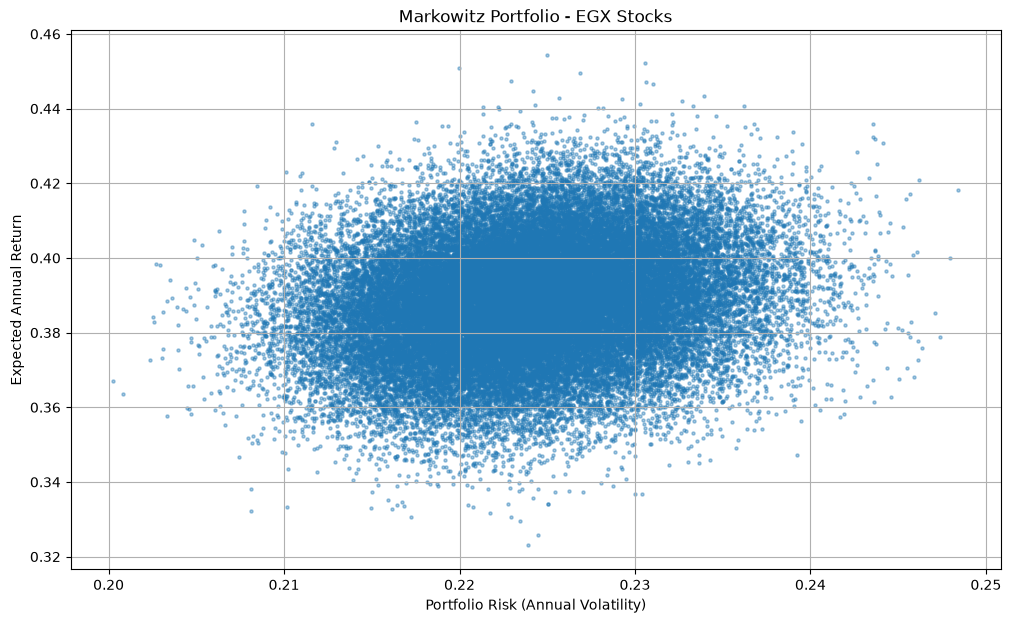

In [28]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolio_risks,
    portfolio_returns,
    s=5,
    alpha=0.4
)

plt.xlabel("Portfolio Risk (Annual Volatility)")
plt.ylabel("Expected Annual Return")
plt.title("Markowitz Portfolio - EGX Stocks")

plt.grid(True)
plt.show()

In [29]:
min_risk_idx = np.argmin(portfolio_risks)

min_risk_return = portfolio_returns[min_risk_idx]
min_risk = portfolio_risks[min_risk_idx]

min_risk_weights = portfolio_weights[min_risk_idx]

print("Minimum Variance Portfolio")
print("---------------------------")
print(f"Return: {min_risk_return:.2%}")
print(f"Risk:   {min_risk:.2%}")

Minimum Variance Portfolio
---------------------------
Return: 36.70%
Risk:   20.02%


In [30]:
min_risk_portfolio = pd.Series(
    min_risk_weights,
    index=annual_returns.index
)

min_risk_portfolio

ABUK     0.041069
ADIB     0.054344
ALCN     0.022371
AMOC     0.042372
ARCC     0.039149
BTFH     0.017929
CCAP     0.004780
CIEB     0.043890
COMI     0.028265
DOMTY    0.066996
EAST     0.056337
EFID     0.021451
EFIH     0.060251
EGAL     0.032734
EMFD     0.052749
ETEL     0.030629
FWRY     0.011456
GBCO     0.017999
HELI     0.002919
HRHO     0.014482
ISPH     0.024772
JUFO     0.031887
MCQE     0.013519
MFPC     0.021204
ORAS     0.067194
ORWE     0.006086
PHDC     0.002549
RAYA     0.034982
RMDA     0.027364
SAUD     0.049739
SKPC     0.009900
SUGR     0.013786
SWDY     0.008109
TMGH     0.026737
dtype: float64

In [31]:
sharpe_ratios = portfolio_returns / portfolio_risks

max_sharpe_idx = np.argmax(sharpe_ratios)

max_sharpe_return = portfolio_returns[max_sharpe_idx]
max_sharpe_risk = portfolio_risks[max_sharpe_idx]
max_sharpe_weights = portfolio_weights[max_sharpe_idx]

print("Maximum Sharpe Ratio Portfolio")
print("--------------------------------")
print(f"Return: {max_sharpe_return:.2%}")
print(f"Risk:   {max_sharpe_risk:.2%}")
print(f"Sharpe: {sharpe_ratios[max_sharpe_idx]:.2f}")

Maximum Sharpe Ratio Portfolio
--------------------------------
Return: 43.58%
Risk:   21.16%
Sharpe: 2.06


In [32]:
max_sharpe_portfolio = pd.Series(
    max_sharpe_weights,
    index=annual_returns.index
)

max_sharpe_portfolio

ABUK     0.027559
ADIB     0.016459
ALCN     0.023398
AMOC     0.016571
ARCC     0.060664
BTFH     0.017905
CCAP     0.018821
CIEB     0.023010
COMI     0.039104
DOMTY    0.060270
EAST     0.036543
EFID     0.061157
EFIH     0.021506
EGAL     0.057179
EMFD     0.024173
ETEL     0.039059
FWRY     0.003218
GBCO     0.000257
HELI     0.013997
HRHO     0.002403
ISPH     0.026325
JUFO     0.027745
MCQE     0.059323
MFPC     0.010765
ORAS     0.028125
ORWE     0.019125
PHDC     0.003719
RAYA     0.006634
RMDA     0.054508
SAUD     0.024693
SKPC     0.047565
SUGR     0.027877
SWDY     0.056722
TMGH     0.043623
dtype: float64

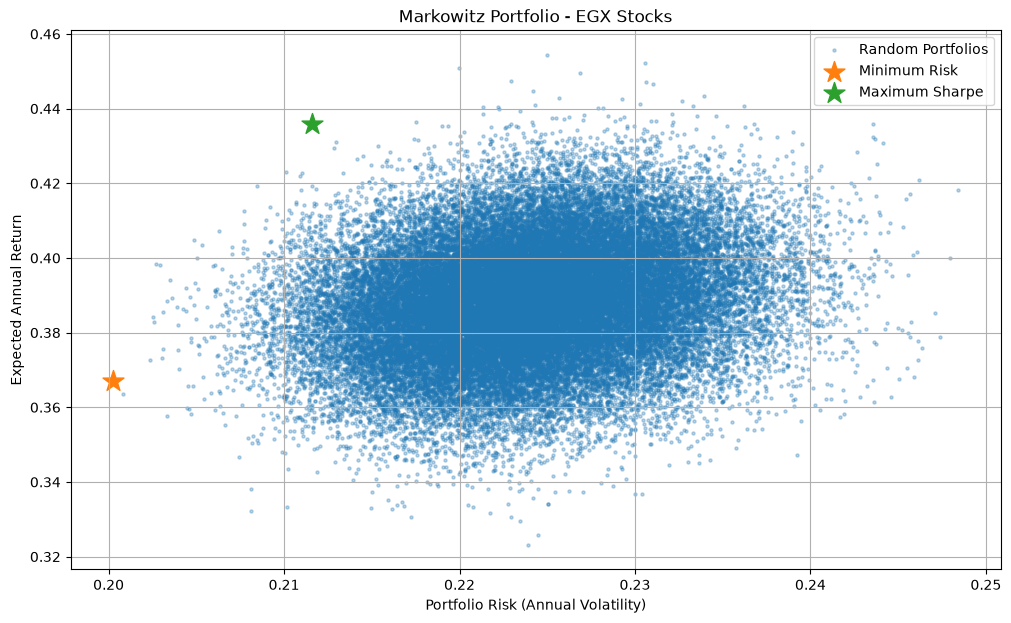

In [33]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolio_risks,
    portfolio_returns,
    s=5,
    alpha=0.3,
    label="Random Portfolios"
)

# Minimum Risk Portfolio
plt.scatter(
    min_risk,
    min_risk_return,
    marker="*",
    s=250,
    label="Minimum Risk"
)

# Maximum Sharpe Portfolio
plt.scatter(
    max_sharpe_risk,
    max_sharpe_return,
    marker="*",
    s=250,
    label="Maximum Sharpe"
)

plt.xlabel("Portfolio Risk (Annual Volatility)")
plt.ylabel("Expected Annual Return")
plt.title("Markowitz Portfolio - EGX Stocks")

plt.legend()
plt.grid(True)
plt.show()

In [34]:
sorted_indices = np.argsort(portfolio_risks)

sorted_risks = portfolio_risks[sorted_indices]
sorted_returns = portfolio_returns[sorted_indices]

In [35]:
efficient_risks = []
efficient_returns = []

max_return_so_far = -np.inf

for risk, ret in zip(sorted_risks, sorted_returns):
    
    if ret > max_return_so_far:
        efficient_risks.append(risk)
        efficient_returns.append(ret)
        max_return_so_far = ret

efficient_risks = np.array(efficient_risks)
efficient_returns = np.array(efficient_returns)

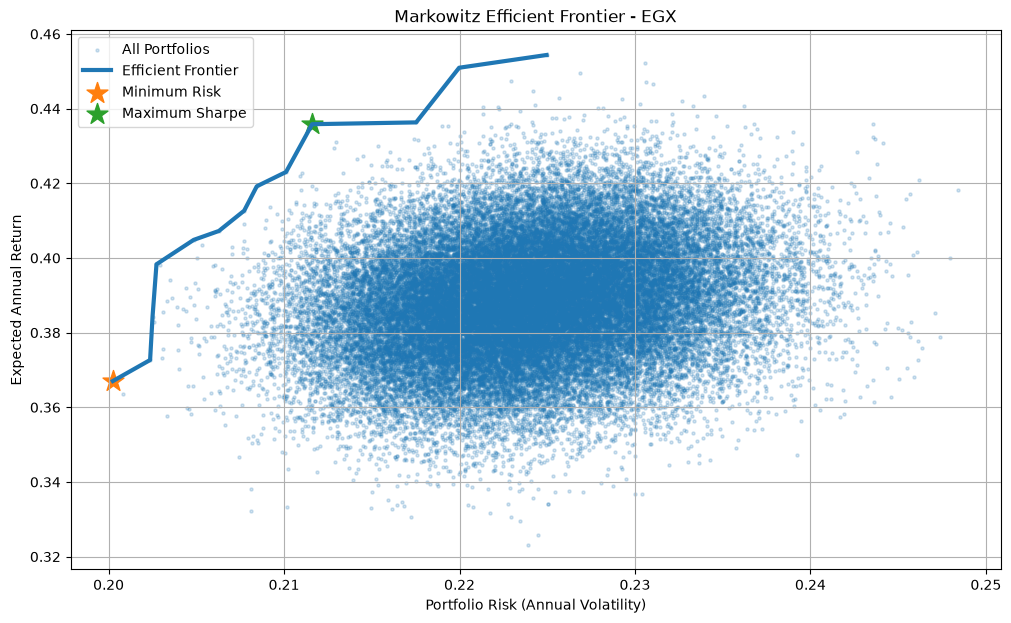

In [36]:
plt.figure(figsize=(12, 7))

# All portfolios
plt.scatter(
    portfolio_risks,
    portfolio_returns,
    s=5,
    alpha=0.2,
    label="All Portfolios"
)

# Efficient Frontier
plt.plot(
    efficient_risks,
    efficient_returns,
    linewidth=3,
    label="Efficient Frontier"
)

# Minimum Risk
plt.scatter(
    min_risk,
    min_risk_return,
    marker="*",
    s=250,
    label="Minimum Risk"
)

# Maximum Sharpe
plt.scatter(
    max_sharpe_risk,
    max_sharpe_return,
    marker="*",
    s=250,
    label="Maximum Sharpe"
)

plt.xlabel("Portfolio Risk (Annual Volatility)")
plt.ylabel("Expected Annual Return")
plt.title("Markowitz Efficient Frontier - EGX")

plt.legend()
plt.grid(True)
plt.show()

In [37]:
weights_df = pd.DataFrame(
    portfolio_weights,
    columns=annual_returns.index
)

weights_df["Return"] = portfolio_returns
weights_df["Risk"] = portfolio_risks
weights_df["Sharpe"] = sharpe_ratios

weights_df.head()

,ABUK,ADIB,ALCN,AMOC,ARCC,BTFH,CCAP,CIEB,COMI,DOMTY,...,RAYA,RMDA,SAUD,SKPC,SUGR,SWDY,TMGH,Return,Risk,Sharpe
0,0.025053,0.063593,0.048963,0.040044,0.010436,0.010434,0.003885,0.057938,0.040209,0.047363,...,0.034397,0.039627,0.003107,0.040639,0.011406,0.004351,0.063471,0.370540,0.222911,1.662278
1,0.057779,0.048371,0.018227,0.005844,0.040942,0.026337,0.007302,0.029629,0.002058,0.054410,...,0.016236,0.049588,0.021347,0.016810,0.032473,0.008432,0.048000,0.400736,0.228310,1.755226
2,0.004653,0.061590,0.048194,0.012401,0.000345,0.050891,0.044114,0.045496,0.048133,0.004621,...,0.030817,0.032623,0.026682,0.001586,0.006733,0.001961,0.039717,0.355951,0.231183,1.539689
3,0.018586,0.030069,0.053659,0.014739,0.024264,0.044672,0.013528,0.004551,0.017131,0.009532,...,0.030198,0.024679,0.013132,0.007087,0.019961,0.055749,0.019109,0.369330,0.226331,1.631814
4,0.032471,0.044002,0.022759,0.060823,0.060239,0.015759,0.031123,0.018832,0.017828,0.002309,...,0.033534,0.005651,0.052281,0.020077,0.011674,0.002552,0.036984,0.389011,0.225672,1.723791


In [38]:
best_portfolio = weights_df.loc[max_sharpe_idx]

best_portfolio

ABUK      0.027559
ADIB      0.016459
ALCN      0.023398
AMOC      0.016571
ARCC      0.060664
BTFH      0.017905
CCAP      0.018821
CIEB      0.023010
COMI      0.039104
DOMTY     0.060270
EAST      0.036543
EFID      0.061157
EFIH      0.021506
EGAL      0.057179
EMFD      0.024173
ETEL      0.039059
FWRY      0.003218
GBCO      0.000257
HELI      0.013997
HRHO      0.002403
ISPH      0.026325
JUFO      0.027745
MCQE      0.059323
MFPC      0.010765
ORAS      0.028125
ORWE      0.019125
PHDC      0.003719
RAYA      0.006634
RMDA      0.054508
SAUD      0.024693
SKPC      0.047565
SUGR      0.027877
SWDY      0.056722
TMGH      0.043623
Return    0.435831
Risk      0.211602
Sharpe    2.059673
Name: 3795, dtype: float64

In [39]:
best_weights = pd.Series(
    max_sharpe_weights,
    index=annual_returns.index
)

print("Maximum Sharpe Ratio Portfolio")
print("=" * 40)

for stock, weight in best_weights.items():
    print(f"{stock}: {weight:.2%}")

print("\nPortfolio Statistics")
print("=" * 40)

print(f"Expected Return : {max_sharpe_return:.2%}")
print(f"Risk            : {max_sharpe_risk:.2%}")
print(f"Sharpe Ratio    : {sharpe_ratios[max_sharpe_idx]:.2f}")

Maximum Sharpe Ratio Portfolio
ABUK: 2.76%
ADIB: 1.65%
ALCN: 2.34%
AMOC: 1.66%
ARCC: 6.07%
BTFH: 1.79%
CCAP: 1.88%
CIEB: 2.30%
COMI: 3.91%
DOMTY: 6.03%
EAST: 3.65%
EFID: 6.12%
EFIH: 2.15%
EGAL: 5.72%
EMFD: 2.42%
ETEL: 3.91%
FWRY: 0.32%
GBCO: 0.03%
HELI: 1.40%
HRHO: 0.24%
ISPH: 2.63%
JUFO: 2.77%
MCQE: 5.93%
MFPC: 1.08%
ORAS: 2.81%
ORWE: 1.91%
PHDC: 0.37%
RAYA: 0.66%
RMDA: 5.45%
SAUD: 2.47%
SKPC: 4.76%
SUGR: 2.79%
SWDY: 5.67%
TMGH: 4.36%

Portfolio Statistics
Expected Return : 43.58%
Risk            : 21.16%
Sharpe Ratio    : 2.06


In [40]:
print("Minimum Risk Portfolio")
print("=" * 40)

for stock, weight in min_risk_portfolio.items():
    print(f"{stock}: {weight:.2%}")

print("\nPortfolio Statistics")
print("=" * 40)

print(f"Expected Return : {min_risk_return:.2%}")
print(f"Risk            : {min_risk:.2%}")

Minimum Risk Portfolio
ABUK: 4.11%
ADIB: 5.43%
ALCN: 2.24%
AMOC: 4.24%
ARCC: 3.91%
BTFH: 1.79%
CCAP: 0.48%
CIEB: 4.39%
COMI: 2.83%
DOMTY: 6.70%
EAST: 5.63%
EFID: 2.15%
EFIH: 6.03%
EGAL: 3.27%
EMFD: 5.27%
ETEL: 3.06%
FWRY: 1.15%
GBCO: 1.80%
HELI: 0.29%
HRHO: 1.45%
ISPH: 2.48%
JUFO: 3.19%
MCQE: 1.35%
MFPC: 2.12%
ORAS: 6.72%
ORWE: 0.61%
PHDC: 0.25%
RAYA: 3.50%
RMDA: 2.74%
SAUD: 4.97%
SKPC: 0.99%
SUGR: 1.38%
SWDY: 0.81%
TMGH: 2.67%

Portfolio Statistics
Expected Return : 36.70%
Risk            : 20.02%


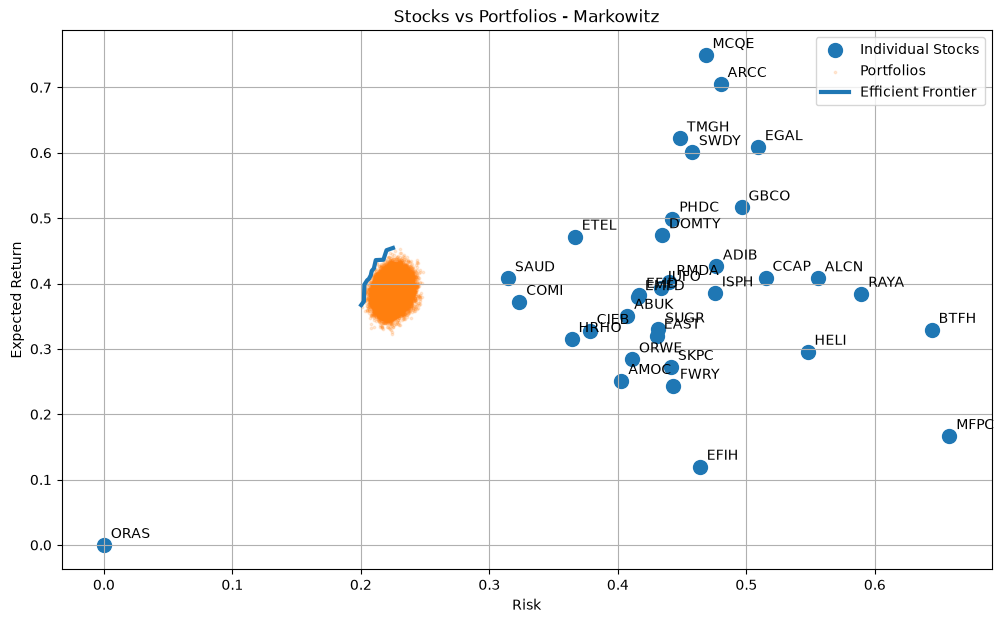

In [41]:
plt.figure(figsize=(12, 7))

# Individual stocks
stock_risks = np.sqrt(np.diag(cov_matrix))

plt.scatter(
    stock_risks,
    annual_returns,
    s=100,
    label="Individual Stocks"
)

for stock, x, y in zip(
    annual_returns.index,
    stock_risks,
    annual_returns
):
    plt.annotate(
        stock,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

# All portfolios
plt.scatter(
    portfolio_risks,
    portfolio_returns,
    s=3,
    alpha=0.15,
    label="Portfolios"
)

# Efficient frontier
plt.plot(
    efficient_risks,
    efficient_returns,
    linewidth=3,
    label="Efficient Frontier"
)

plt.xlabel("Risk")
plt.ylabel("Expected Return")
plt.title("Stocks vs Portfolios - Markowitz")

plt.legend()
plt.grid(True)
plt.show()